# Fréchet Means for Alpha Connections

The exponential barycenter is the affine-connection analogue of the Fréchet mean:

$$\frac{1}{N} \sum_{i=1}^N \log_{\bar{x}}^{(\alpha)}(x_i) = 0$$

where $\log^{(\alpha)}$ is the logarithm of the $\alpha$-connection.

Gradient descent on the connection gives:

$$\bar{x}_{t+1} = \exp_{\bar{x}_t}^{(\alpha)}\!\left(\eta \cdot \frac{1}{N}\sum_i \log_{\bar{x}_t}^{(\alpha)}(x_i)\right)$$

For $\alpha = 0$ (Fisher-Rao connection), the exponential barycenter should match the Riemannian Fréchet mean.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

import geomstats.backend as gs
import geomstats.visualization as visualization
from geomstats.information_geometry.normal import (
    UnivariateNormalAlpha,
    UnivariateNormalDistributions,
)
from geomstats.learning.exponential_barycenter import GeneralExponentialBarycenter
from geomstats.learning.frechet_mean import FrechetMean
from scipy.stats import norm

# Simulation Setup

## Define the Alpha Space

In [2]:
def create_alpha_space(alpha, riemannian_manifold):
    space = UnivariateNormalDistributions(equip=False)
    space.equip_with_connection(
        UnivariateNormalAlpha,
        riemannian_manifold=riemannian_manifold,
        alpha=alpha,
    )
    return space

## Analytic Cases for $\alpha=-1$ and $\alpha=1$

In [3]:
def mixture_barycenter(points):
    mu_bar = 0
    for i in range(len(points)):
        mu_bar += points[i][0]
    mu_bar /= len(points)
    sigma_bar = sum(pt[1] ** 2 + (pt[0] - mu_bar) ** 2 for pt in points)
    sigma_bar /= len(points)
    sigma_bar = np.sqrt(sigma_bar)
    return mu_bar, sigma_bar

def exponential_barycenter(points):
    denominator = 0
    sigma_bar = 0
    for i in range(len(points)):
        denominator += 1 / points[i][1] ** 2
    sigma_bar = np.sqrt(len(points) / denominator)
    mu_bar = 0
    for i in range(len(points)):
        mu_bar += points[i][0] / points[i][1] ** 2
    mu_bar /= denominator
    return mu_bar, sigma_bar

## Alpha Barycenters and the Fréchet Mean

In [4]:
alphas = [-1.0, -0.5, 0.0, 0.5, 1.0]
riemannian_manifold = UnivariateNormalDistributions(equip=True)

def compute_barycenters(points, alphas, riemannian_manifold):
    means = {}
    for alpha in alphas:
        space = create_alpha_space(alpha, riemannian_manifold)
        estimator = GeneralExponentialBarycenter(space)
        estimator.fit(points)
        means[alpha] = estimator.estimate_

    frechet = FrechetMean(riemannian_manifold)
    frechet.fit(points)
    riemannian_mean = frechet.estimate_
    return means, riemannian_mean

## Poincaré Half-Plane View

In [5]:
def plot_barycenters(alphas, points, means, riemannian_mean):
    colors = plt.cm.viridis(np.linspace(0, 1, len(alphas)))
    alpha_styles = {
        alpha: (colors[i], rf"$\alpha$={alpha:.4f}")
        for i, alpha in enumerate(alphas)
    }
    fig, ax = plt.subplots(figsize=(15, 7))
    visualization.plot(
        points,
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="o",
        color="black",
        s=10,
        alpha=0.6,
        label="Data points",
    )
    for alpha, (color, label) in alpha_styles.items():
        visualization.plot(
            means[alpha][None],
            ax=ax,
            space="H2_poincare_half_plane",
            coords_type="half-space",
            marker="x",
            color=color,
            s=100,
            label=label,
        )
    visualization.plot(
        riemannian_mean[None],
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="o",
        color="green",
        s=250,
        label="Riemannian Fréchet mean",
        alpha=0.3,
    )

    mu_mix, sigma_mix = mixture_barycenter(points)
    mu_exp, sigma_exp = exponential_barycenter(points)
    ax.plot(
        mu_mix,
        sigma_mix,
        marker="+",
        color="black",
        markersize=10,
        label="Mixture barycenter",
    )
    ax.plot(
        mu_exp,
        sigma_exp,
        marker="+",
        color="black",
        markersize=10,
        label="Exponential barycenter",
    )

    ax.set_title(
        "Barycenters for different alpha values and the Riemannian Fréchet mean",
        fontsize=16,
    )
    ax.set_xlabel("$\\mu$")
    ax.set_ylabel("$\\sigma$")
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

    plt.tight_layout()
    plt.show()

## Parameter Evolution with Alpha

In [6]:
def set_min_yspan(ax, epsilon):
    ymin, ymax = ax.get_ylim()
    mid = (ymin + ymax) / 2
    if ymax - ymin < epsilon:
        ax.set_ylim(mid - epsilon / 2, mid + epsilon / 2)

def plot_alpha_parameter_evolution(alphas, means, epsilon = 0.1):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(
        alphas,
        [means[alpha][0] for alpha in alphas],
        "o",
        linestyle="--",
        markersize=4,
        linewidth=1.5,
        color="grey",
    )
    ax1.grid(True)

    ax1.set_xlabel(r"$\alpha$")
    ax1.set_ylabel("Barycenter mean")
    ax1.set_title(r"Barycenter mean vs $\alpha$")

    set_min_yspan(ax1, epsilon)

    ax2.plot(
        alphas,
        [means[alpha][1] for alpha in alphas],
        "o",
        linestyle="--",
        markersize=4,
        linewidth=1.5,
        color="grey",
    )
    ax2.grid(True)

    set_min_yspan(ax2, epsilon)

    ax2.set_xlabel(r"$\alpha$")
    ax2.set_ylabel("Barycenter variance")
    ax2.set_title(r"Barycenter variance vs $\alpha$")

    plt.suptitle(
        r"Evolution of the exponential barycenter with respect to $\alpha$",
        fontsize=16,
    )
    plt.tight_layout()
    plt.show()

## Density Comparisons

In [7]:
def plot_densities(points, means, alphas, riemannian_mean, x_min, x_max):
    x = np.linspace(x_min, x_max, 300)

    fig, ax = plt.subplots(figsize=(10, 5))
    for mu, sigma in points:
        ax.plot(
            x,
            norm.pdf(x, mu, sigma),
            linestyle="--",
            linewidth=0.5,
            color="gray",
        )

    mu, sigma = points[0]
    ax.plot(
        x,
        norm.pdf(x, mu, sigma),
        linestyle="--",
        linewidth=0.5,
        color="gray",
        label="Data densities",
    )

    colors = plt.cm.viridis(np.linspace(0, 1, len(means)))
    for i in range(len(means)):
        mu, sigma = means[alphas[i]]
        ax.plot(
            x,
            norm.pdf(x, mu, sigma),
            color=colors[i],
            label=rf"$\alpha$={alphas[i]}",
        )

    x = np.linspace(x_min, x_max, 30)
    mu, sigma = riemannian_mean
    ax.plot(
        x,
        norm.pdf(x, loc=mu, scale=sigma),
        color="black",
        marker="o",
        markersize=2,
        linestyle="none",
        label="Riemannian Fréchet mean",
    )

    ax.set_xlim(x_min, x_max)
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    ax.set_title("Data densities and alpha-barycenter densities in $\\mathbb{R}^2$", fontsize=16)
    plt.tight_layout()
    plt.show()

# Simulations

### Default Settings

In [8]:
riemannian_manifold = UnivariateNormalDistributions(equip=True)
alphas = np.linspace(-1.0, 1.0, 21)
alphas_reduced = [-1.0, -0.5, 0.0, 0.5, 1.0]
alphas_test =[0.0]

## Random Points in the Poincaré Half-Plane

### Sample Generation

In [9]:
n_points = 20
mus = [random.uniform(-5,5) for _ in range(n_points)]
sigmas = [random.uniform(0.5,5.0) for _ in range(n_points)]

random_points = gs.array(np.stack([mus, sigmas], axis=-1))

print([(float(random_points[i][0]),float(random_points[i][1])) for i in range(len(random_points))])

[(2.593169104581845, 2.422182408042362), (1.5597868908930792, 0.7752852905551173), (-4.0828135007135415, 3.179833564060135), (-0.04178929381443908, 1.0593311149387197), (0.7402116618765238, 2.6138485470102024), (1.959996747866576, 1.9064336418925882), (-1.3347223217552795, 2.1989510448075897), (-1.7449883736514247, 1.382188032970781), (-3.2869762881085, 3.8352056883801966), (1.097332054451785, 4.087751730964534), (3.020173467293805, 1.0667927795032437), (-3.6447332509289976, 1.433805102664834), (-4.226219977606764, 4.031832288761036), (-1.6905068744280394, 0.8772630702765145), (0.09543665209778851, 4.72268898196355), (0.7825011290406199, 3.7238497933340833), (0.48842420322842095, 4.281429213915528), (2.4279260080715463, 1.8622837883710557), (-4.514170789169251, 1.3273043180765565), (3.927855583279385, 2.7056400054557628)]


### Plotting

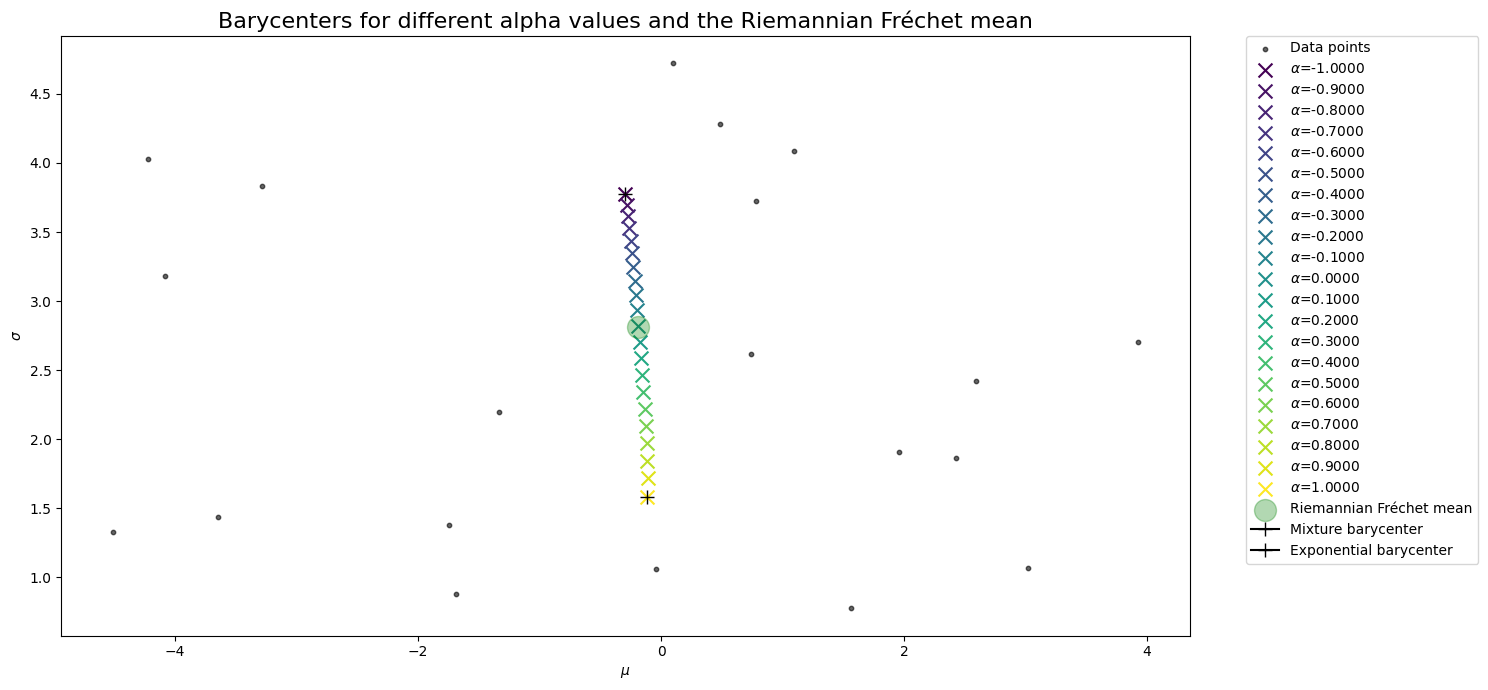

In [10]:
means_random, riemannian_mean_random = compute_barycenters(random_points, alphas, riemannian_manifold)
plot_barycenters(alphas, random_points, means_random, riemannian_mean_random)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


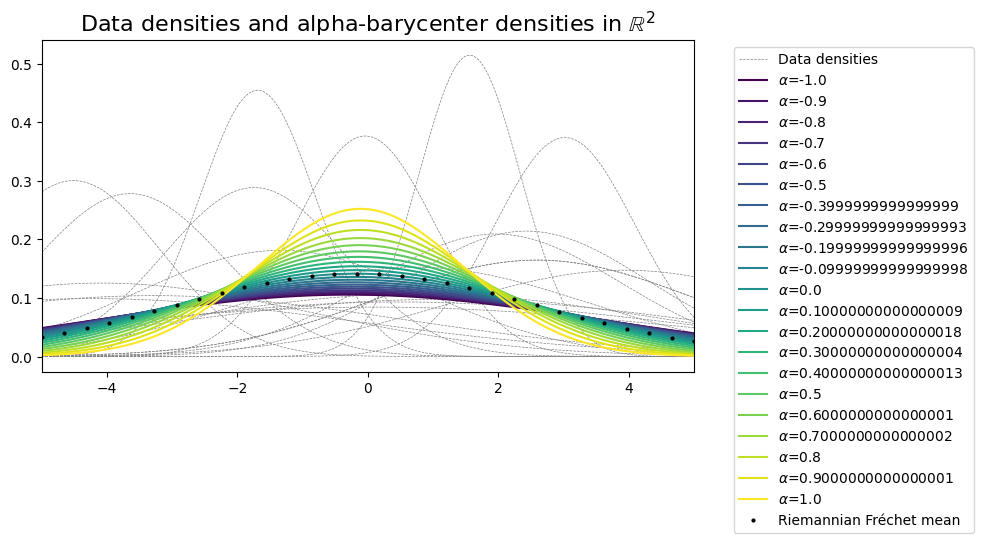

In [11]:
plot_densities(random_points, means_random, alphas, riemannian_mean_random, x_min=-5.0, x_max=5.0)

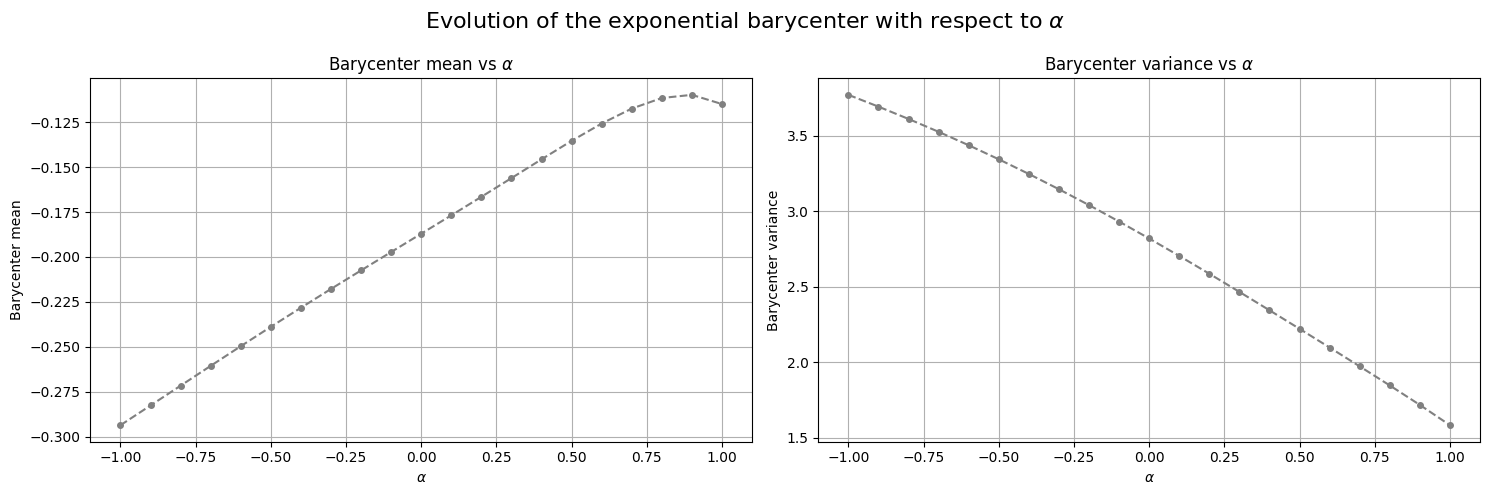

In [12]:
plot_alpha_parameter_evolution(alphas, means_random)

## Sphere Comparisons

### Sample Generation

<Axes: xlabel='X', ylabel='Y'>

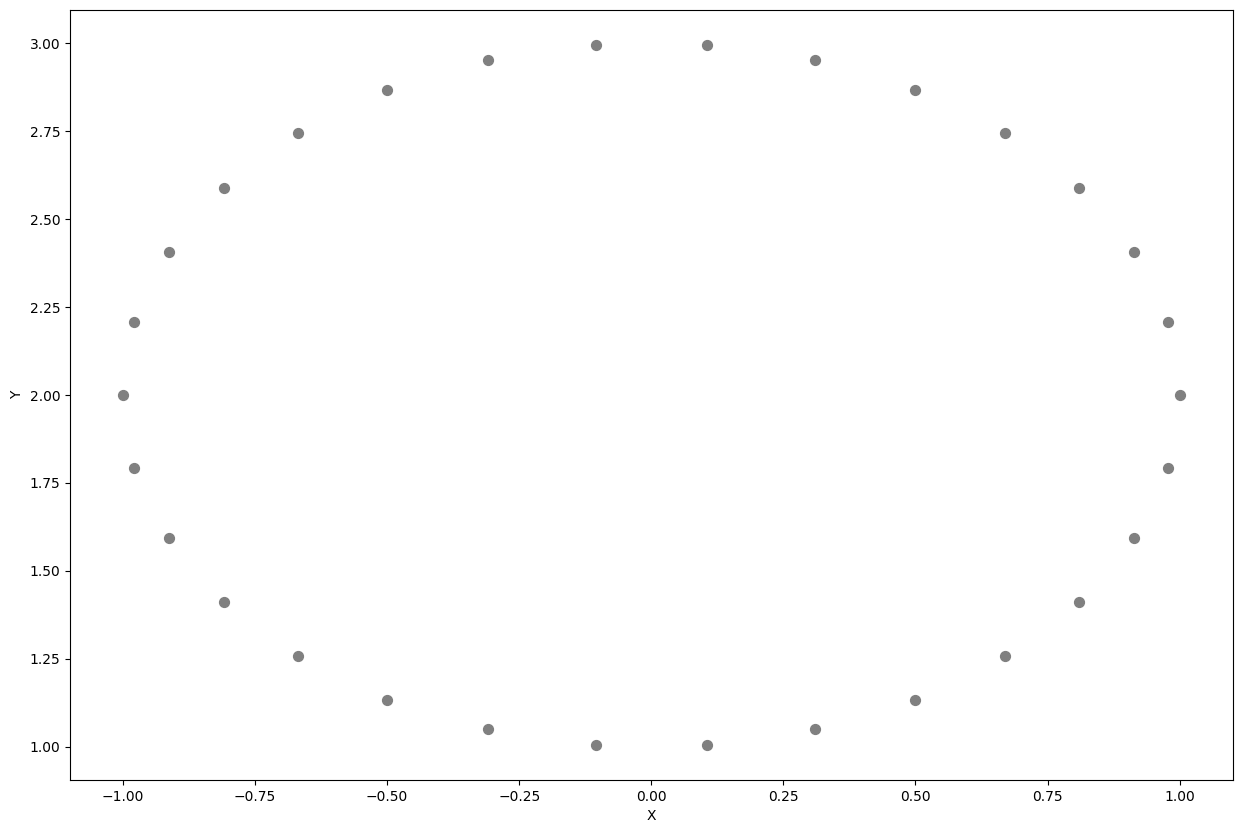

In [13]:
def generate_symmetric_sphere_points(n_points, seed=0):
    """Generate evenly spaced points on the circle centered at (0, 2)."""
    theta = gs.linspace(0, 2 * gs.pi, n_points, endpoint=False)
    center = gs.array([0.0, 2.0])

    pts = gs.stack(
        [
            center[0] + gs.cos(theta),
            center[1] + gs.sin(theta),
        ],
        axis=-1,
    )

    return gs.array(pts)

points_sphere = generate_symmetric_sphere_points(n_points=30, seed=42)

fig, ax = plt.subplots(figsize=(15, 10))
visualization.plot(
        points_sphere,
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="o",
        color="gray",
        s=50,
        label="Data points",
    )

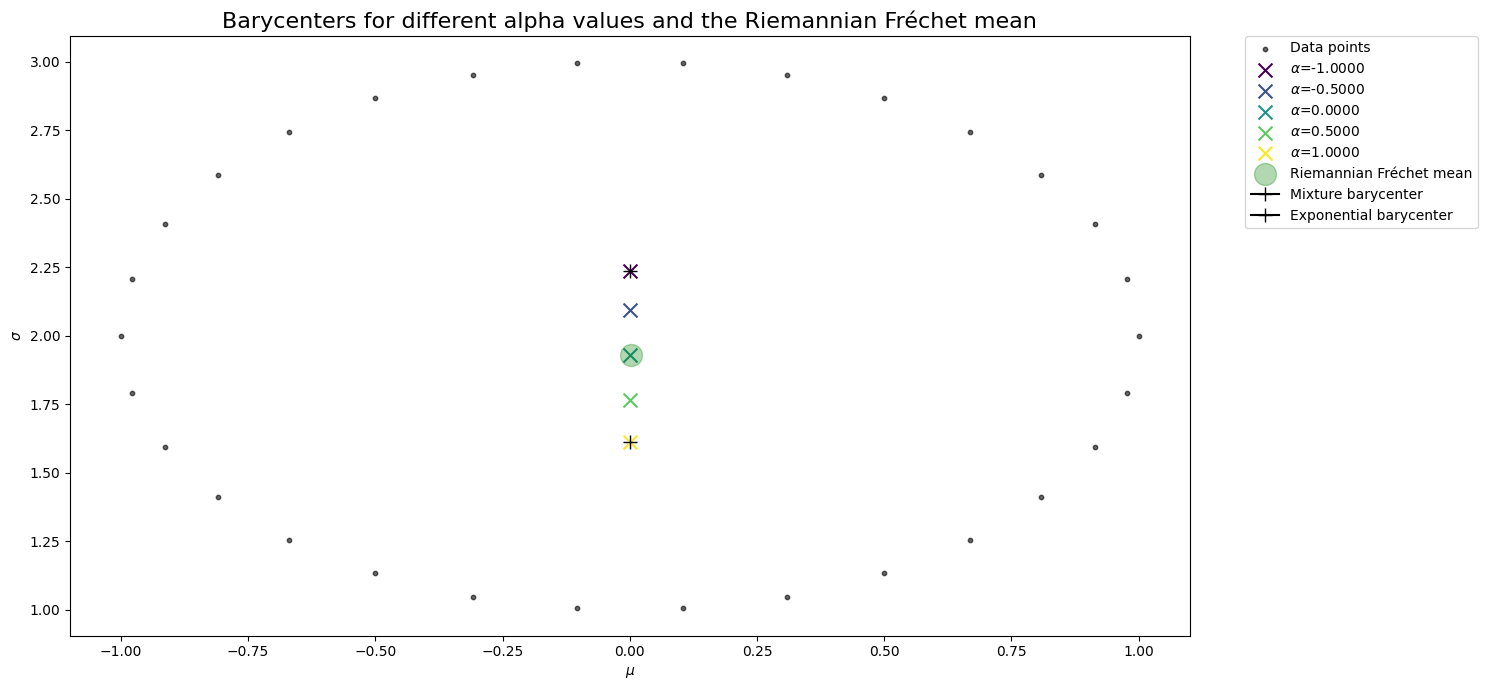

In [14]:
means_sphere, riemannian_mean_sphere = compute_barycenters(points_sphere, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_sphere, means_sphere, riemannian_mean_sphere)

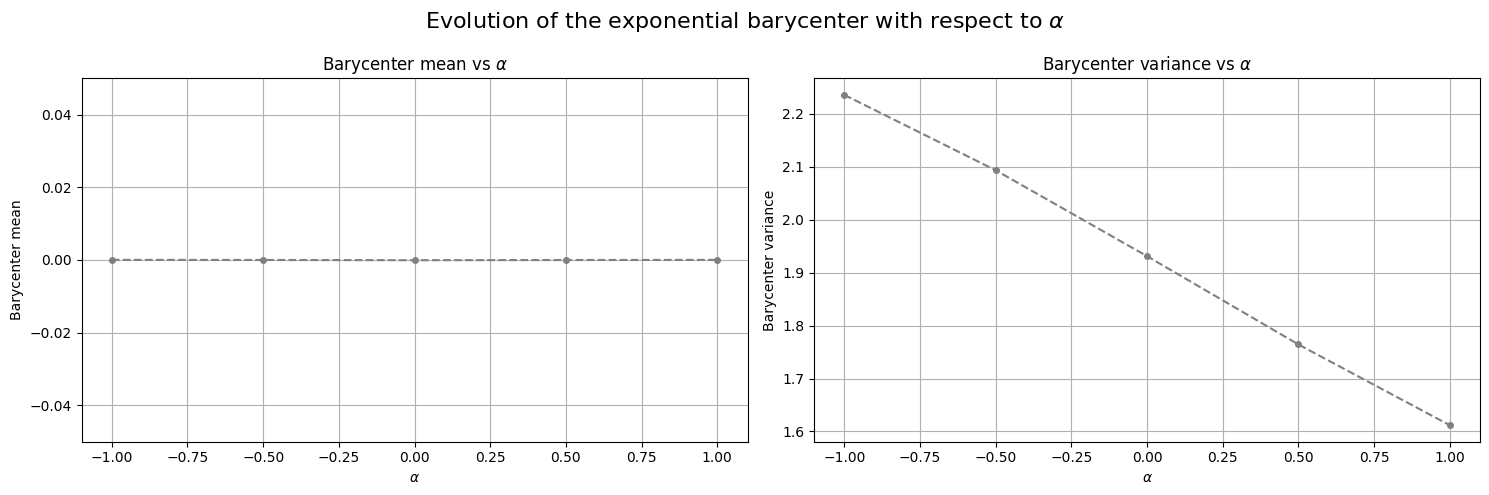

In [15]:
plot_alpha_parameter_evolution(alphas_reduced, means_sphere)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


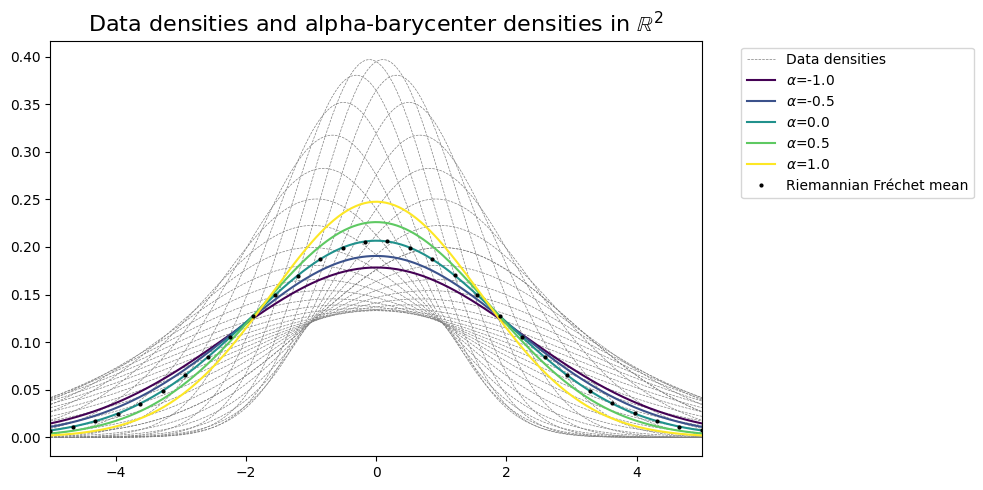

In [16]:
plot_densities(points_sphere, means_sphere, alphas_reduced, riemannian_mean_sphere, x_min=-5.0, x_max=5.0)

## Asymmetric Sphere Case

<Axes: xlabel='X', ylabel='Y'>

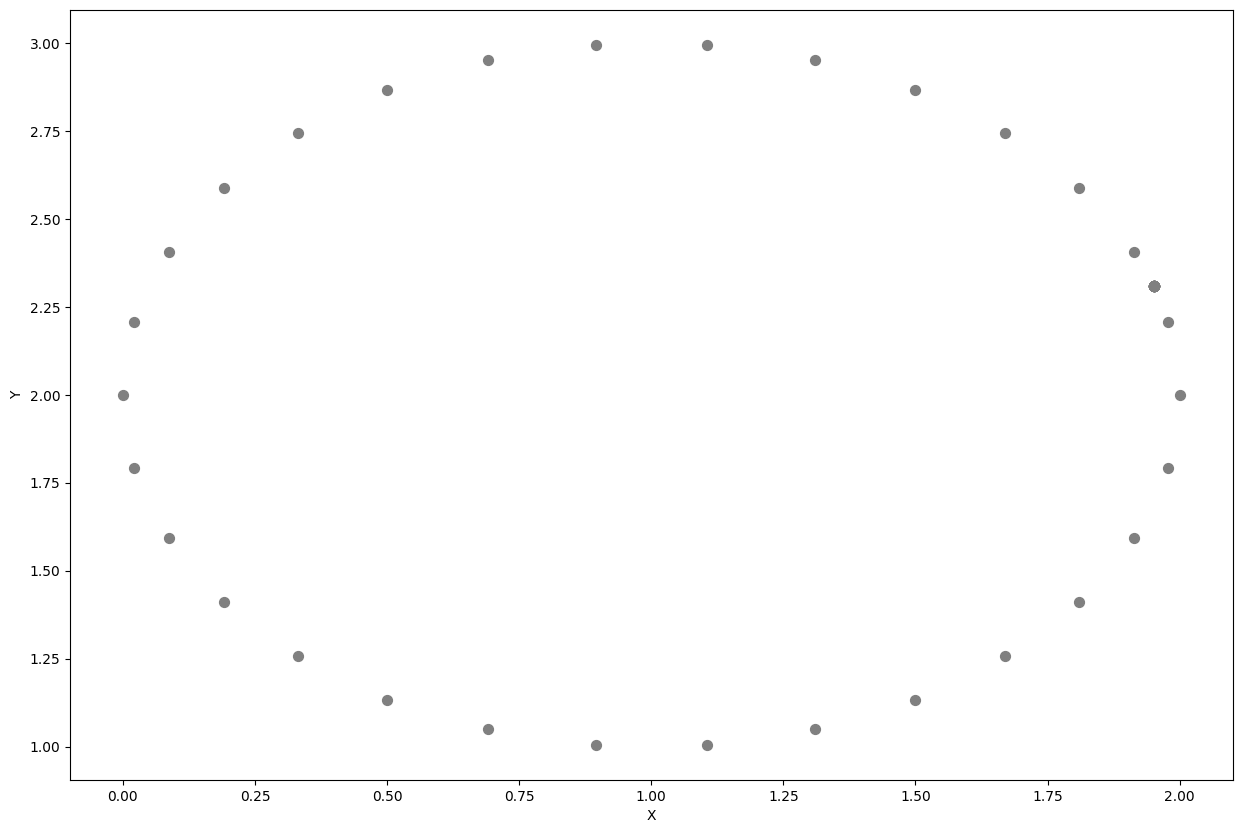

In [17]:
def generate_asymmetric_sphere_points(n_points, seed=0):
    """Generate evenly spaced points on the circle centered at (1, 2)."""
    theta = gs.linspace(0, 2 * gs.pi, n_points, endpoint=False)
    theta_trap = 0.1 * gs.pi
    theta_trap_bis = 0.1 * gs.pi + gs.pi
    center = gs.array([1.0, 2.0])

    pts = gs.stack(
        [
            center[0] + gs.cos(theta),
            center[1] + gs.sin(theta),
        ],
        axis=-1,
    )

    pt = [center[0] + gs.cos(theta_trap), center[1] + gs.sin(theta_trap)]
    pts_supp = gs.array([pt]*n_points)
    pts = gs.concatenate([pts, gs.array([pt])])
    pts = gs.concatenate([pts, pts_supp])

    return gs.array(pts)

points_sphere_asym = generate_asymmetric_sphere_points(n_points=30, seed=42)

fig, ax = plt.subplots(figsize=(15, 10))
visualization.plot(
        points_sphere_asym,
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker="o",
        color="gray",
        s=50,
        label="Data points",
    )

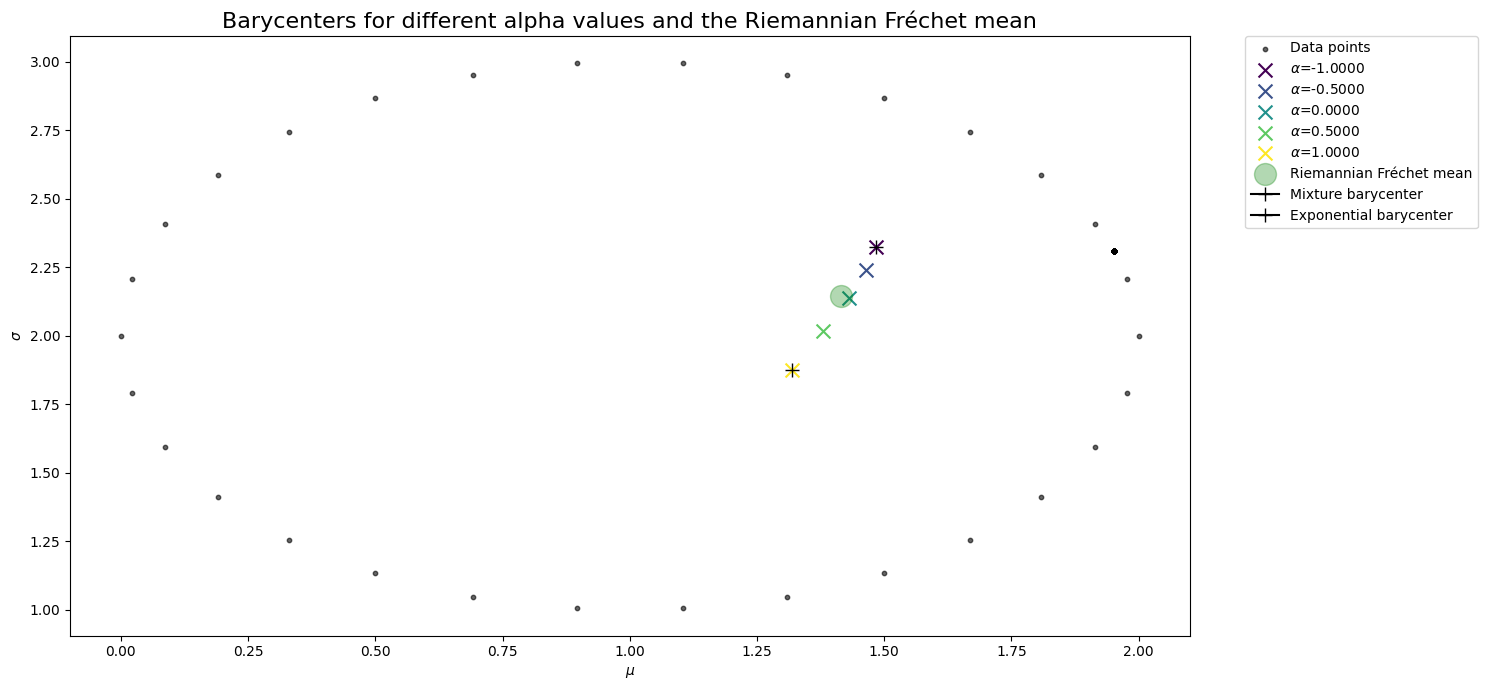

In [18]:
means_sphere_asym, riemannian_mean_sphere_asym = compute_barycenters(points_sphere_asym, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_sphere_asym, means_sphere_asym, riemannian_mean_sphere_asym)

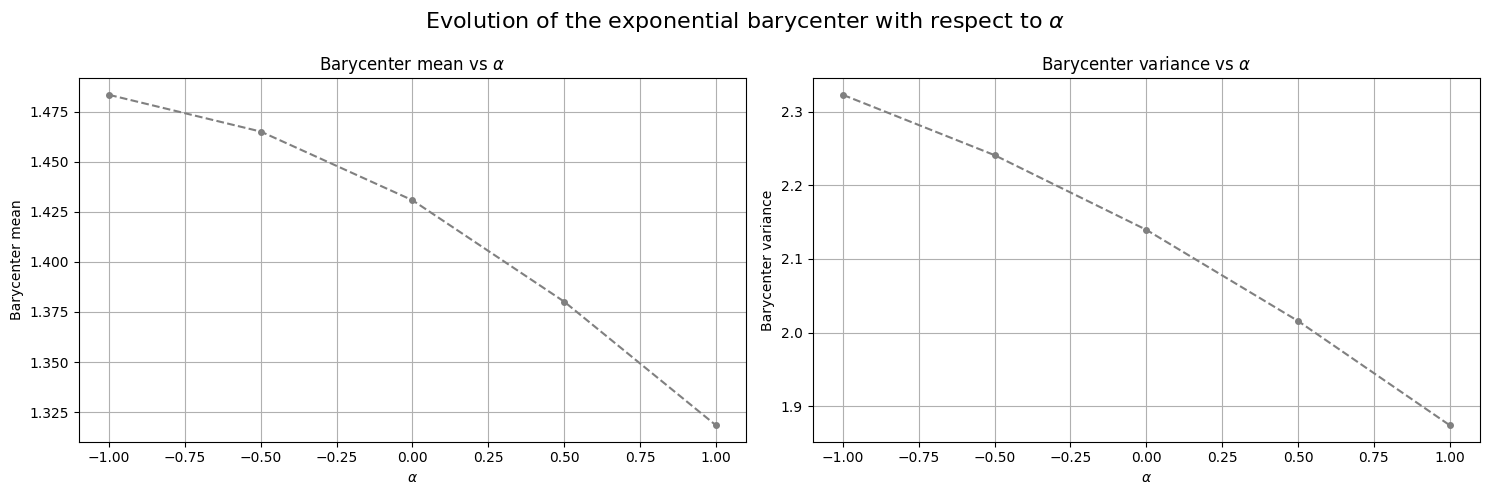

In [19]:
plot_alpha_parameter_evolution(alphas_reduced, means_sphere_asym)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


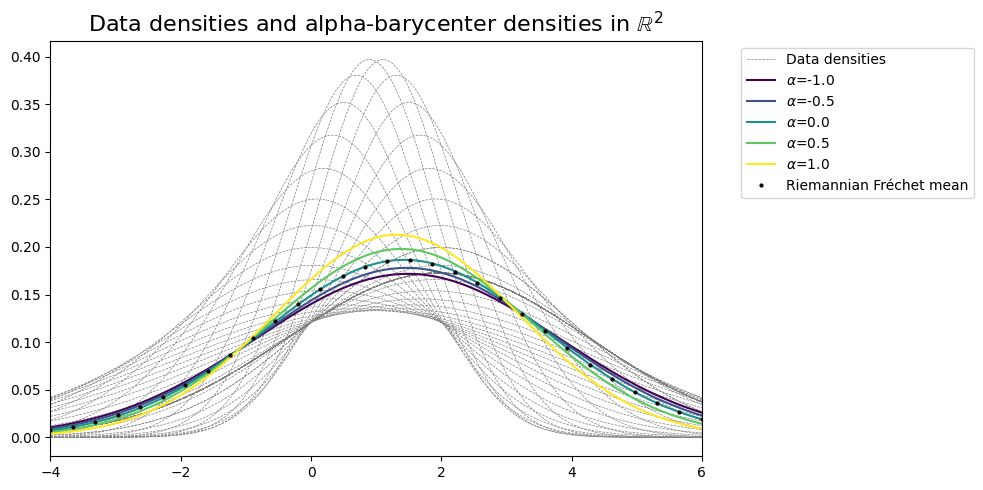

In [20]:
plot_densities(points_sphere_asym, means_sphere_asym, alphas_reduced, riemannian_mean_sphere_asym, x_min=-4.0, x_max=6.0)

## Geodesic Check

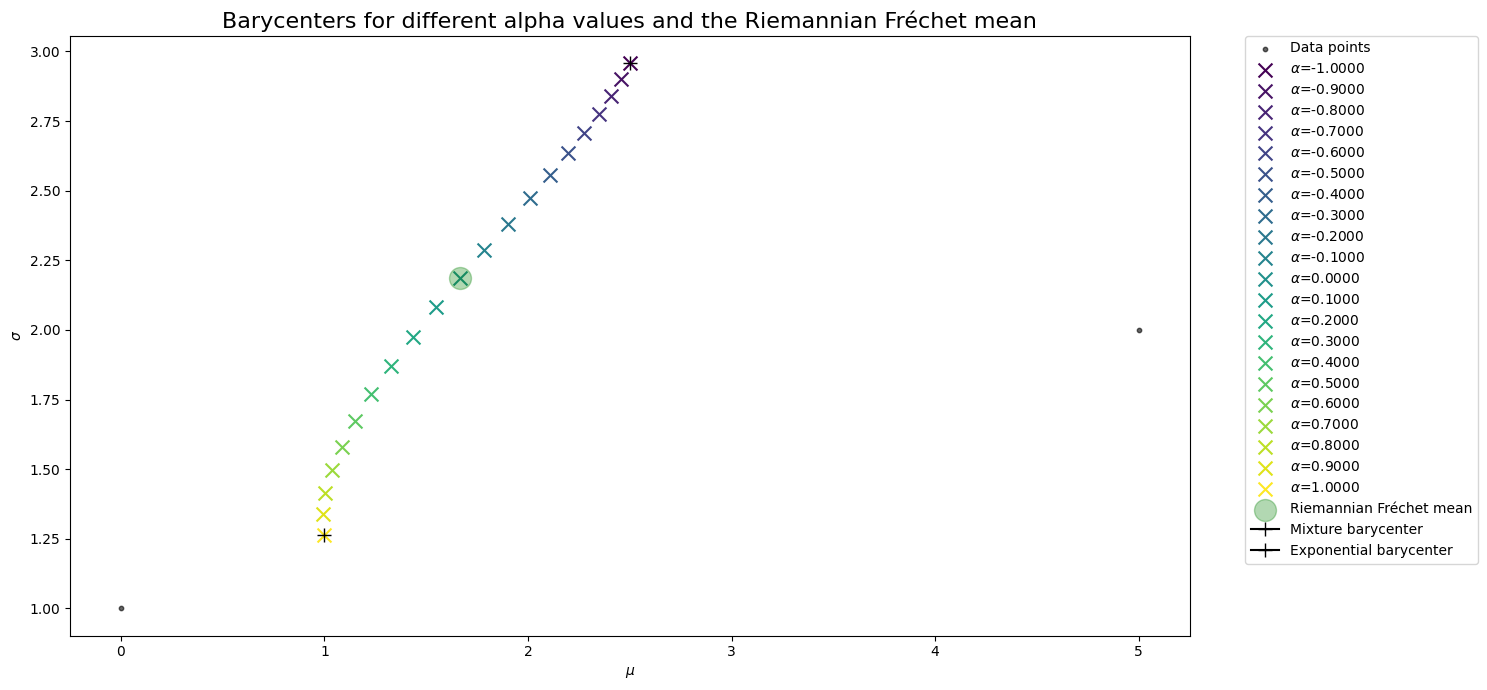

In [21]:
point_1 = gs.array([[0.0, 1.0]])
point_2 = gs.array([[5.0, 2.0]])
points = gs.concatenate([point_1, point_2])
means_geod, riemannian_mean_geod = compute_barycenters(points, alphas, riemannian_manifold)
plot_barycenters(alphas, points, means_geod, riemannian_mean_geod)

## Other Examples

### Vertical and Horizontal Cases

In [22]:
mu_vals = np.linspace(-2, 2, 20)
sigma_val = 1.0
points_horizontal = np.array([[mu, sigma_val] for mu in mu_vals])
# Gaussians with the same scale and different means

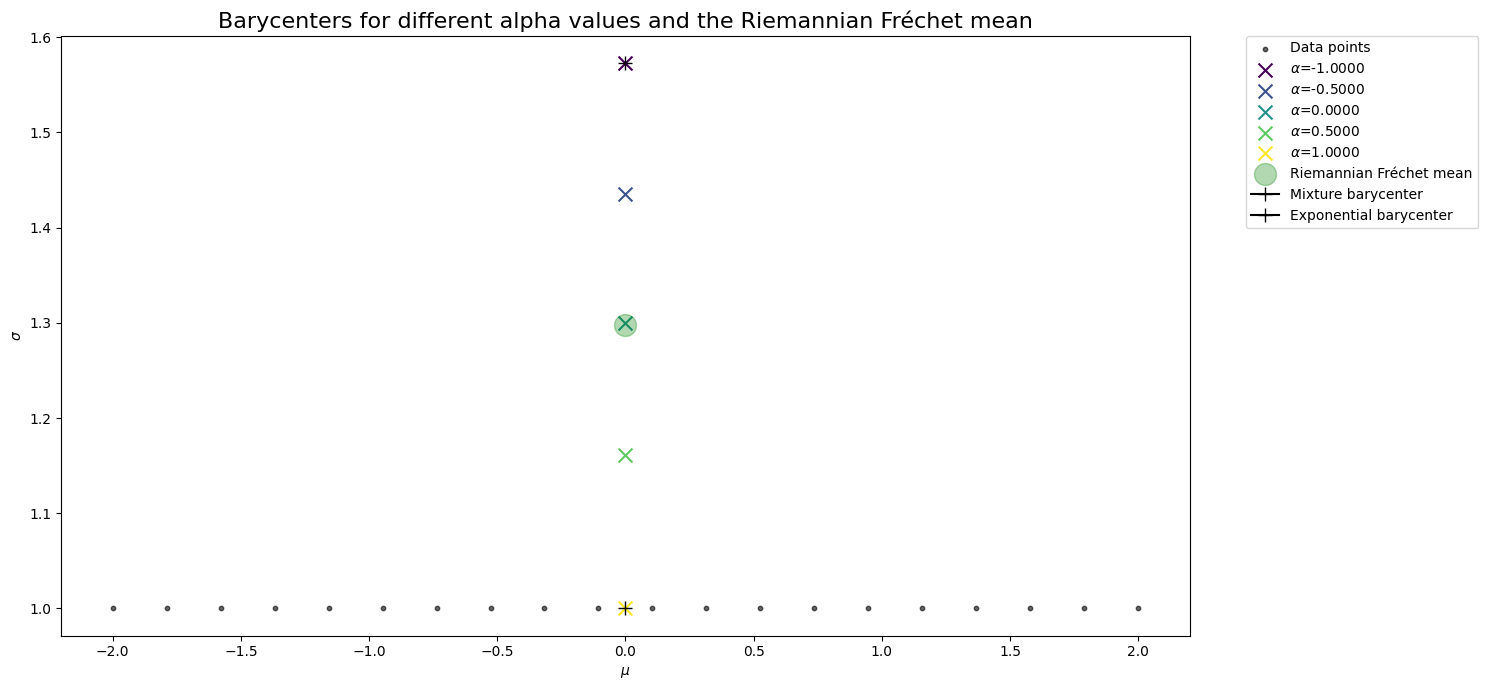

In [23]:
means_horizontal, riemannian_mean_horizontal = compute_barycenters(points_horizontal, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_horizontal, means_horizontal, riemannian_mean_horizontal)

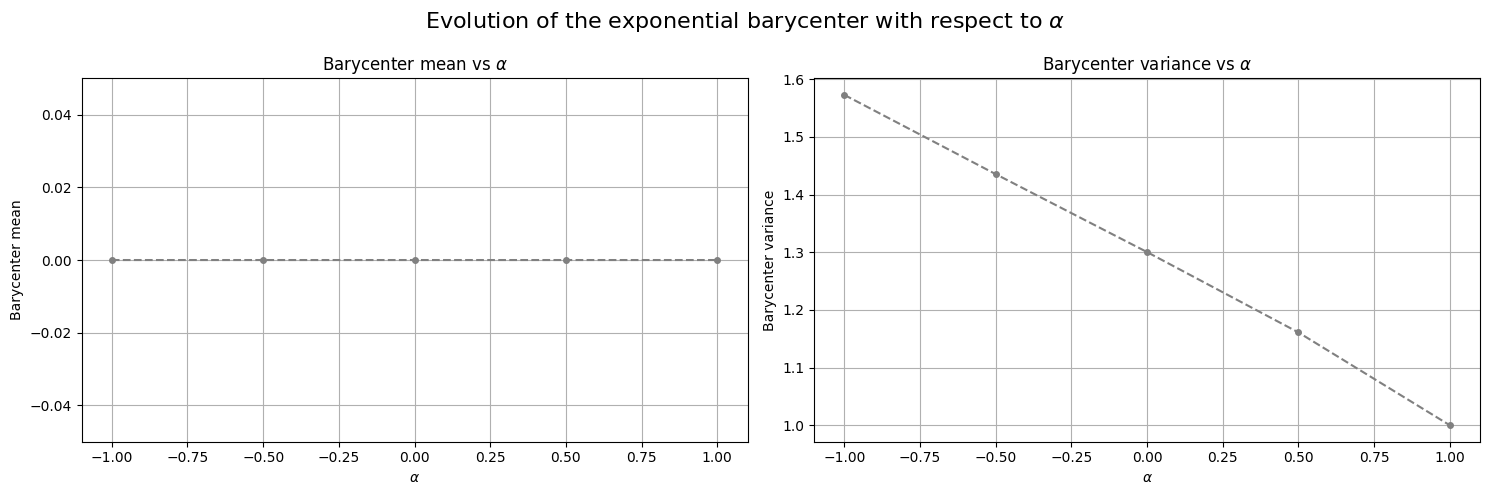

In [24]:
plot_alpha_parameter_evolution(alphas_reduced, means_horizontal)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


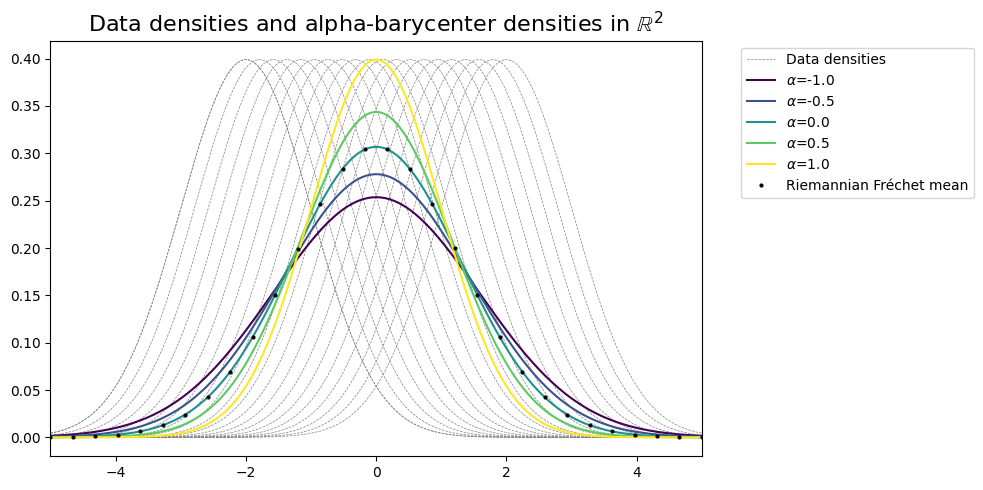

In [25]:
plot_densities(points_horizontal, means_horizontal, alphas_reduced, riemannian_mean_horizontal, x_min=-5.0, x_max=5.0)

In [26]:
mu_val = 0.0
sigma_vals = np.linspace(0.5, 2.5, 20)
points_vertical = np.array([[mu_val, sigma] for sigma in sigma_vals])
# Gaussians with the same mean and increasing scale

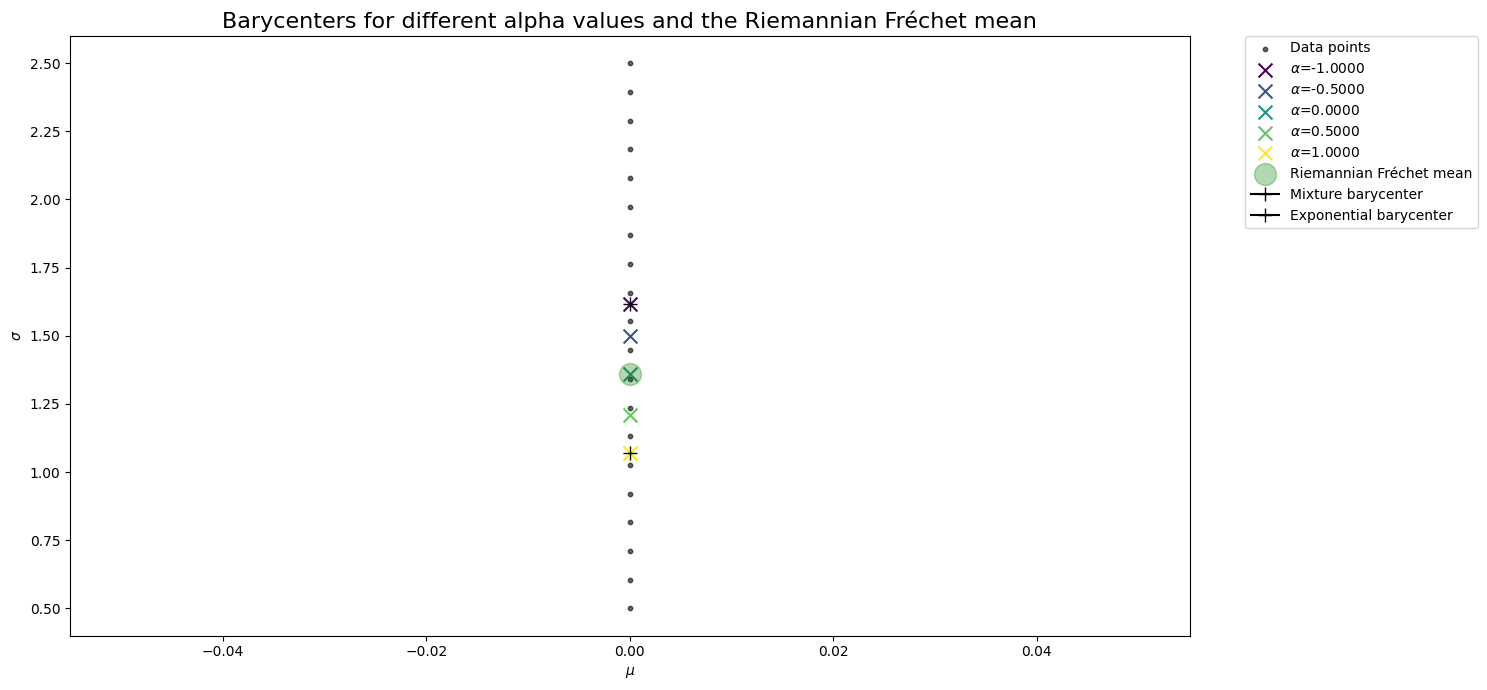

In [27]:
means_vertical, riemannian_mean_vertical = compute_barycenters(points_vertical, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_vertical, means_vertical, riemannian_mean_vertical)

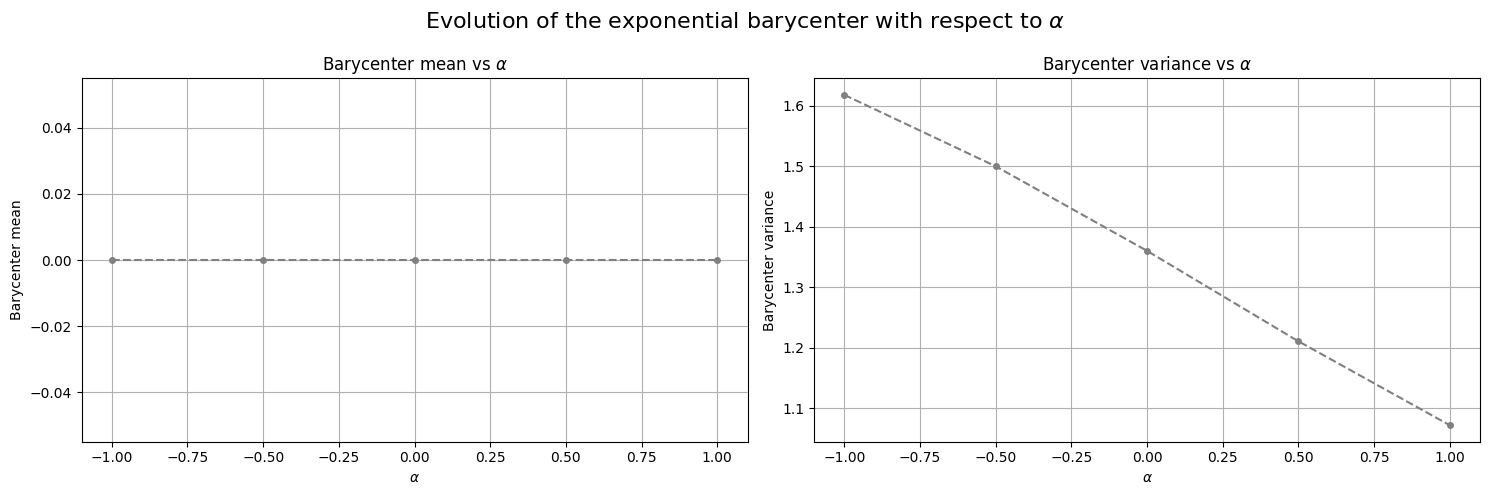

In [28]:
plot_alpha_parameter_evolution(alphas_reduced, means_vertical)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


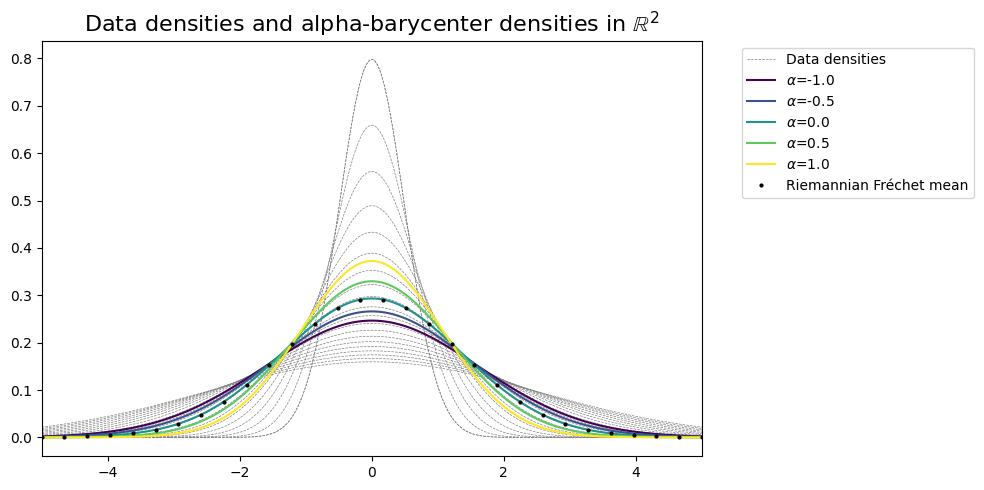

In [29]:
plot_densities(points_vertical, means_vertical, alphas_reduced, riemannian_mean_vertical, x_min=-5.0, x_max=5.0)

### Ellipse

In [30]:
t = np.linspace(0, 2 * np.pi, 20, endpoint=False)
a, b = 1.5, 0.8      # semi-axes
mu_center, sigma_center = 0.0, 1.5
points_ellipse = np.array([
    [mu_center + a * np.cos(ti), sigma_center + b * np.sin(ti)]
    for ti in t
])
# keep sigma positive, so sigma_center > b
# ellipse centered at (0, 1.5) with semi-axes a=1.5 and b=0.8



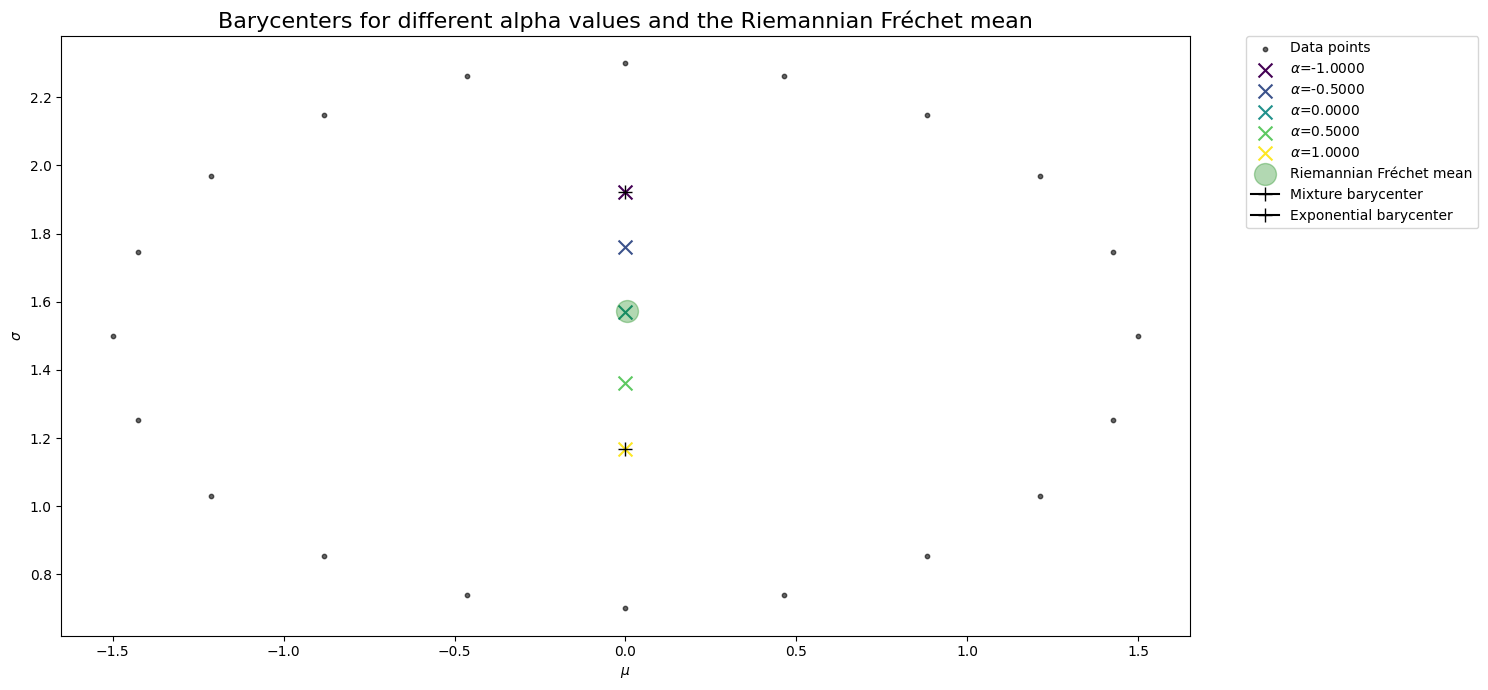

In [31]:
means_ellipse, riemannian_mean_ellipse = compute_barycenters(points_ellipse, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_ellipse, means_ellipse, riemannian_mean_ellipse)

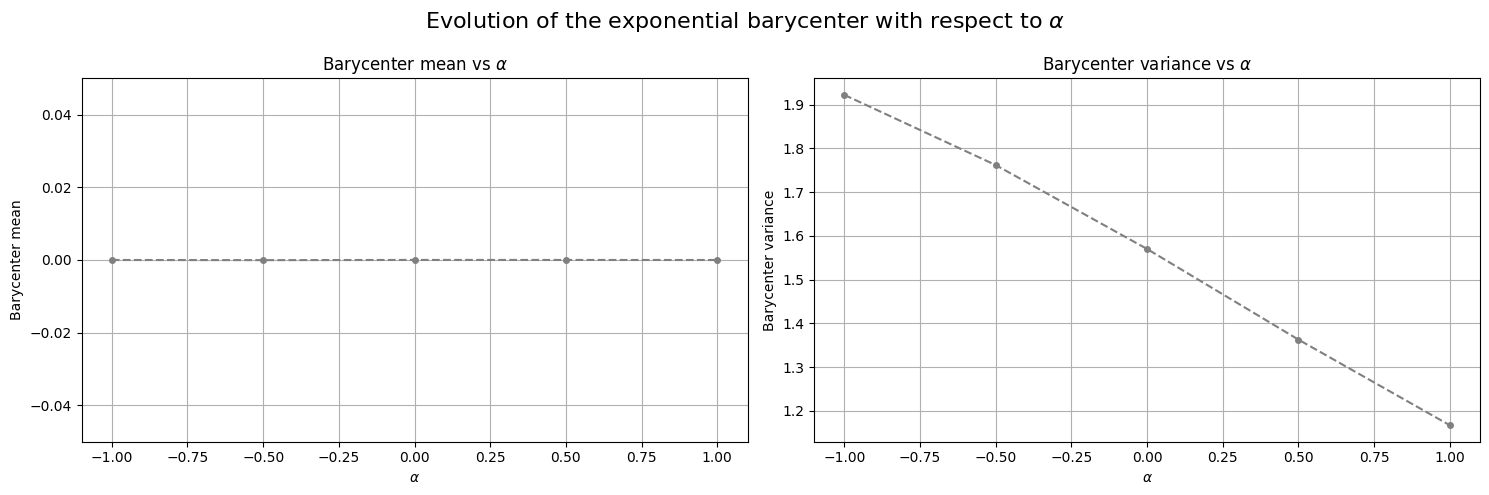

In [32]:
plot_alpha_parameter_evolution(alphas_reduced, means_ellipse)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


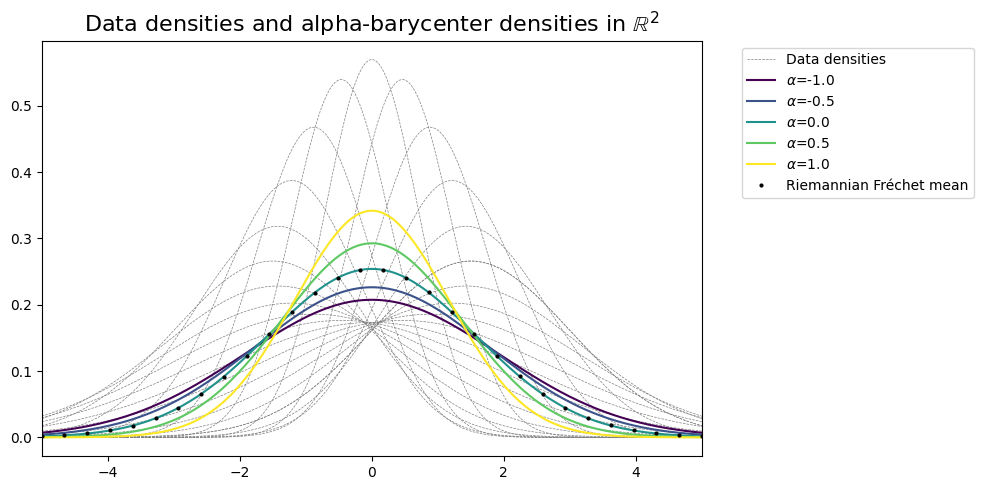

In [33]:
plot_densities(points_ellipse, means_ellipse, alphas_reduced, riemannian_mean_ellipse, x_min=-5.0, x_max=5.0)

### Diagonal

In [34]:
# Points on the diagonal mu = sigma
mu_vals = np.linspace(-2, 2, 20)
sigma_vals = np.linspace(0.5, 2.5, 20)
points_diag = np.array([[mu, sigma] for mu, sigma in zip(mu_vals, sigma_vals)])
# larger values to the right correspond to wider Gaussians


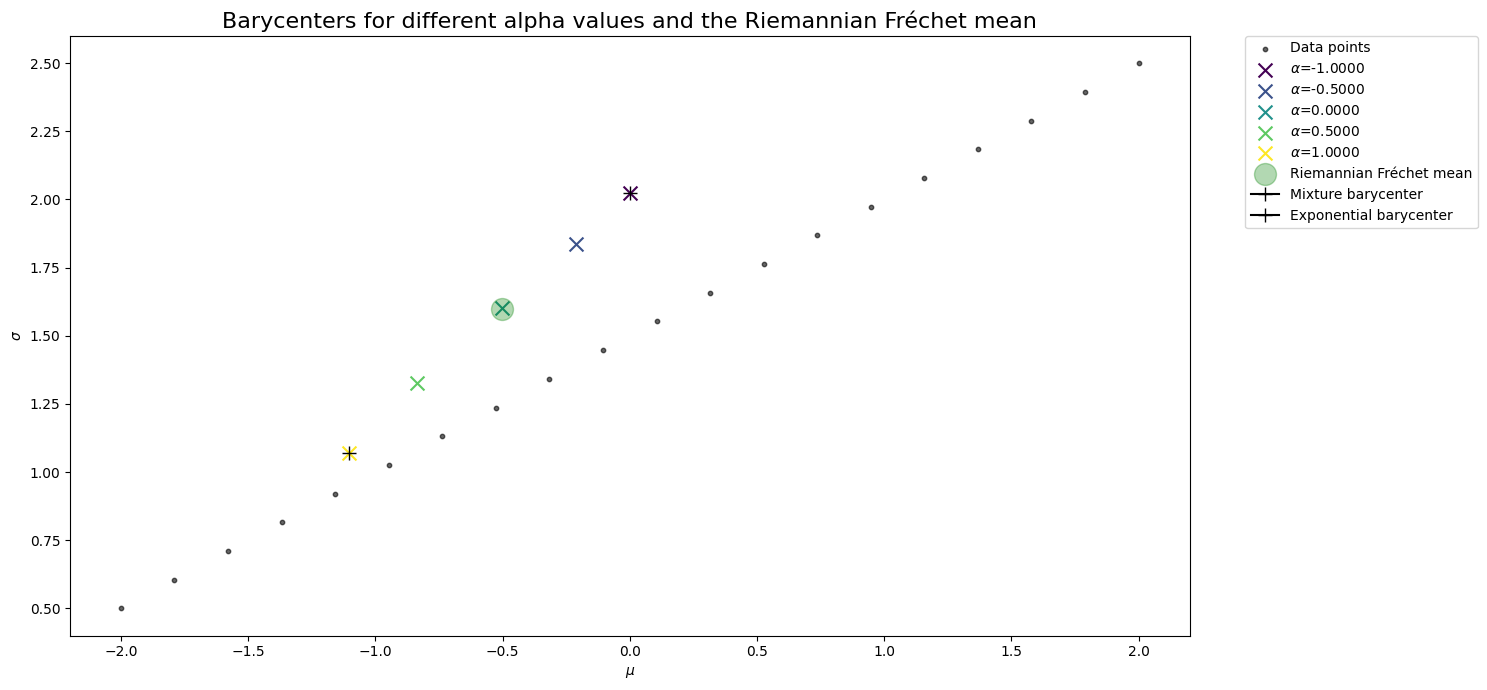

In [35]:
means_diag, riemannian_mean_diag = compute_barycenters(points_diag, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_diag, means_diag, riemannian_mean_diag)

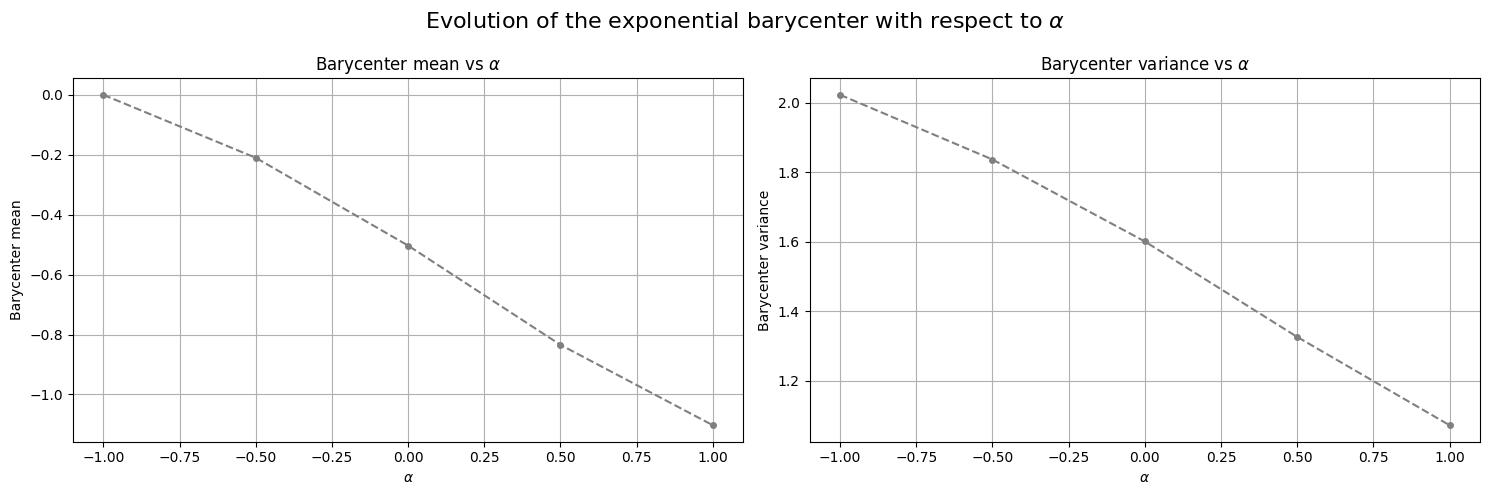

In [36]:
plot_alpha_parameter_evolution(alphas_reduced, means_diag)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


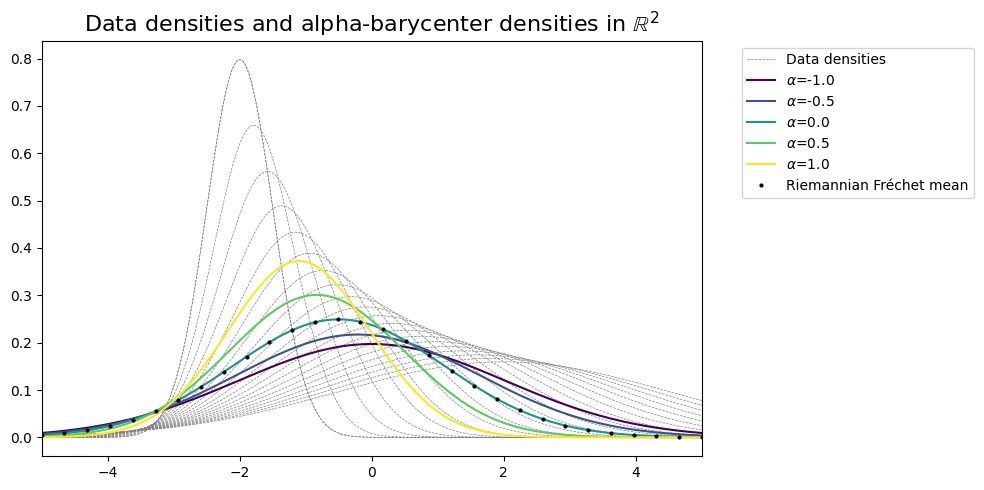

In [37]:
plot_densities(points_diag, means_diag, alphas_reduced, riemannian_mean_diag, x_min=-5.0, x_max=5.0)

### Grid

In [38]:
# Regular grid
mus = np.linspace(-1, 1, 3)
sigmas = np.linspace(0.5, 1.5, 3)
points_grid = np.array([[mu, sigma] for mu in mus for sigma in sigmas])


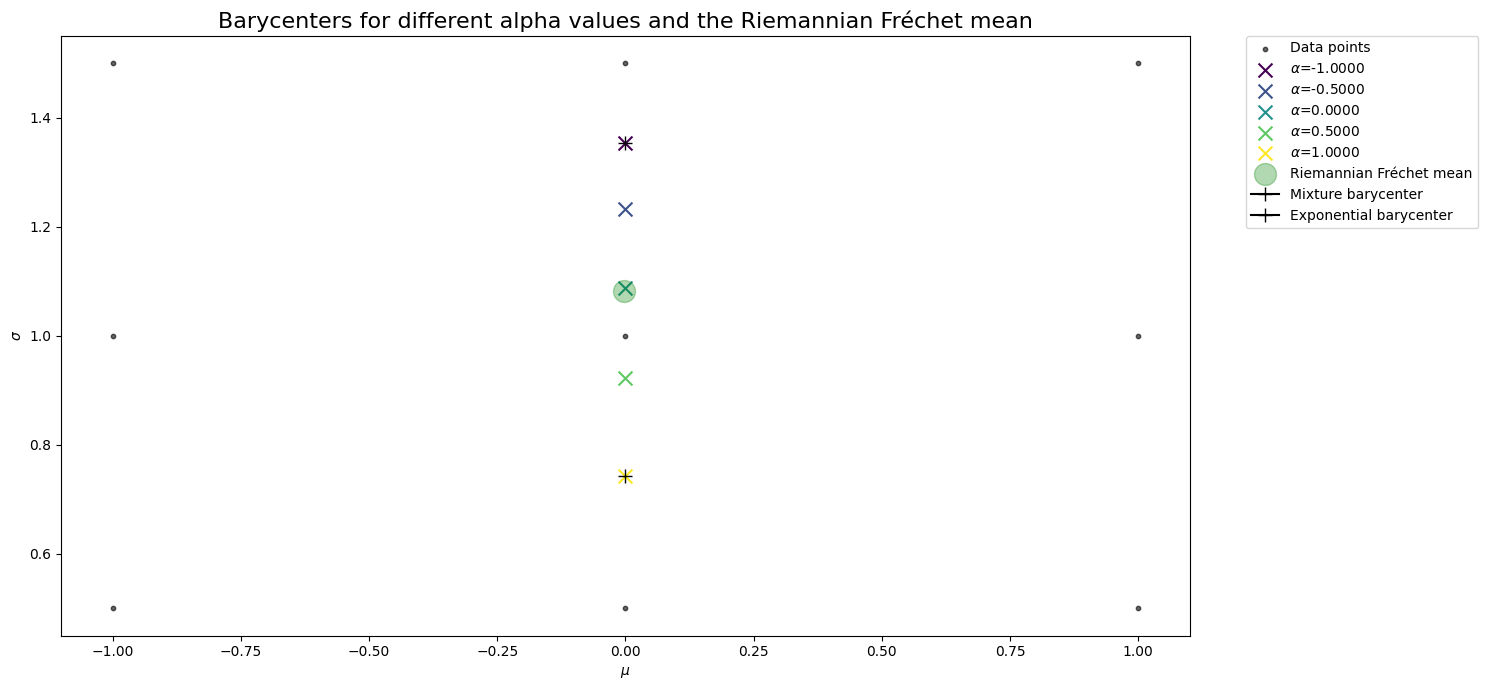

In [39]:
means_grid, riemannian_mean_grid = compute_barycenters(points_grid, alphas_reduced, riemannian_manifold)
plot_barycenters(alphas_reduced, points_grid, means_grid, riemannian_mean_grid)

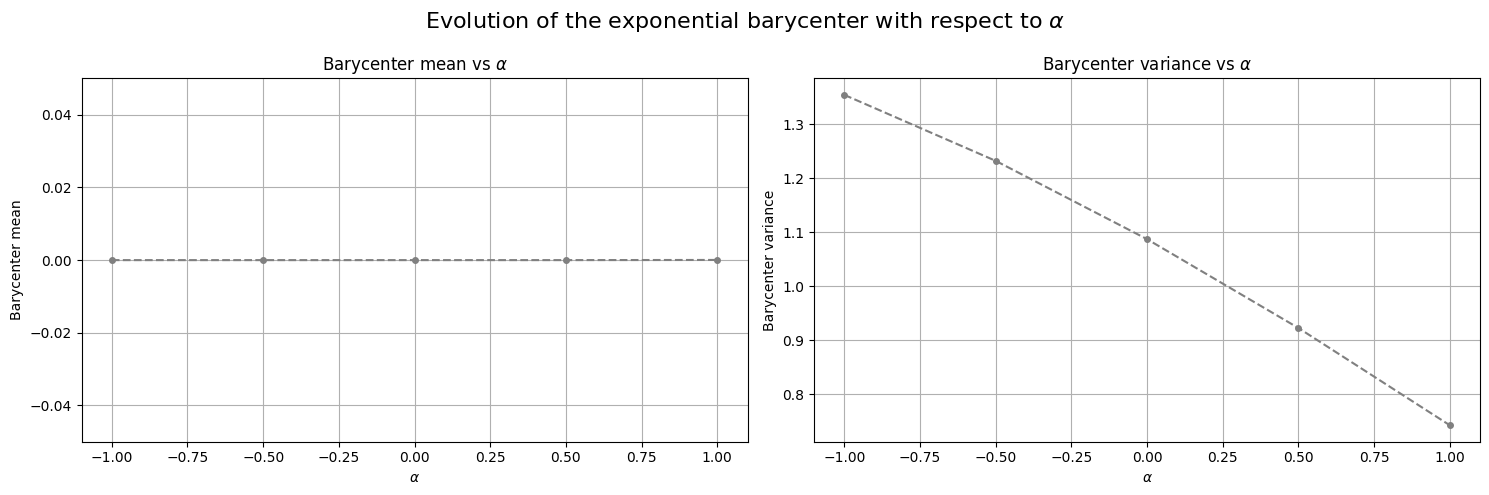

In [40]:
plot_alpha_parameter_evolution(alphas_reduced, means_grid)

INFO: Substituting symbol R from STIXGeneral
INFO: Substituting symbol R from STIXGeneral


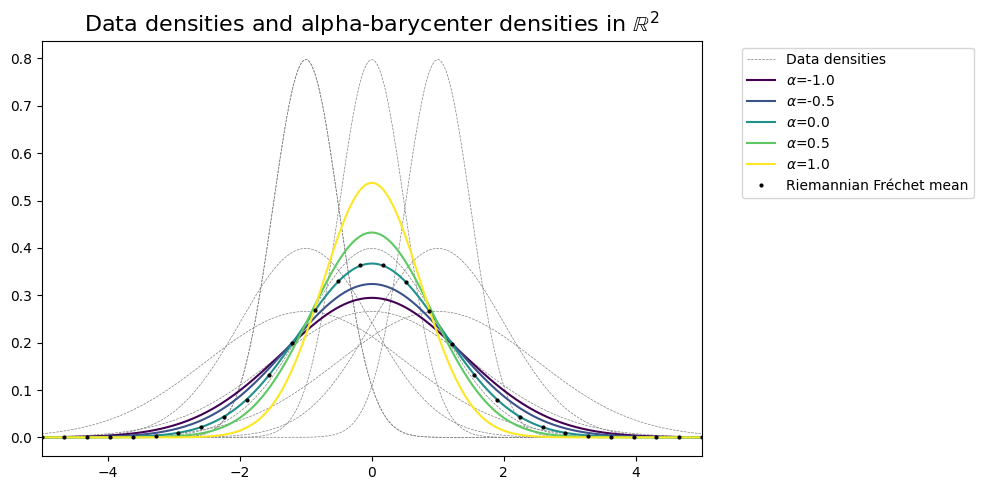

In [41]:
plot_densities(points_grid, means_grid, alphas_reduced, riemannian_mean_grid, x_min=-5.0, x_max=5.0)